In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors  # serve per to_hex
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
import seaborn as sns

In [3]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits")
image_data_2 = hdul2[0].data
image_error_2 = hdul2[1].data
image_cut_2 = image_data_2[49:149, 0:1890]
image_error_cut_2 = image_error_2[49:149, 0:1890]
z = 0.04263
l_HA = 6563 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/PSF/Real_seeing_FIRST_1.txt")
sigmas = seeing / 2.35

wavelenghts = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut_2[:, mask_HA]
image_error_HA = image_error_cut_2[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))
sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
fit = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Fit/Halpha_fit.csv", index_col=0)

In [4]:
spectra = []

for i in range(1, 21):
    df = pd.read_csv(f"Spectrum_{i}_gas_exp.csv")
    spectra.append(df)
    
SNR_HA = pd.read_csv("SNR_HA.csv")
SNR_HB = pd.read_csv("SNR_HB.csv") 
SNR_NII_2 = pd.read_csv("SNR_NII_2.csv") 
SNR_OIII_2 = pd.read_csv("SNR_OIII_2.csv") 
SNR_SII_1 = pd.read_csv("SNR_SII_1.csv") 

In [9]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def ratio(spectrum_1):
    flux = spectrum_1['Flux']
    err_flux = spectrum_1['Error_flux']

    OIII = flux[8]
    HB   = flux[1]
    NII  = flux[12]
    HA   = flux[2]
    SII  = flux[3]

    OIII_HB = np.log10(OIII / HB) if OIII > 0 and HB > 0 else np.nan
    NII_HA  = np.log10(NII / HA)  if NII > 0 and HA > 0 else np.nan
    SII_HA  = np.log10(SII / HA)  if SII > 0 and HA > 0 else np.nan

    err_OIII_HB = error_ratio(err_flux[8], err_flux[1], OIII, HB)
    err_NII_HA  = error_ratio(err_flux[12], err_flux[2], NII, HA)
    err_SII_HA  = error_ratio(err_flux[3], err_flux[2], SII, HA)

    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

def evaluation_SNR(SNR_HA, SNR_HB, SNR_NII, SNR_SII, SNR_OIII):
    if (SNR_HB < 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3): # and (SNR_SII >= 3):
        return True 
    elif (SNR_HB >= 3) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3): # and (SNR_SII >= 3):
        return True 
    else: return False 

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, params):
    """ Profilo Sérsic 1D centrato in x_0 """
    I_e, r_e, n, x_0 = params
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, params1, params2, params3, params4, params5, params6):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, params1) +
        sersic_1d(x_hr, params2) +
        sersic_1d(x_hr, params3) +
        sersic_1d(x_hr, params4) +
        sersic_1d(x_hr, params5) + 
        sersic_1d(x_hr, params6)
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def sersic_1d_convolved(x, sigma, params):
    """ Sérsic convoluto con PSF gaussiana """
    I_e, r_e, n, x_0 = params
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, params)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

Nan: 1
6.713 0.43 2.074 1.353 3.705
Nan: 7
21.914 1.285 8.704 11.309 3.294
Nan: 8
13.055 2.987 5.351 11.483 1.232
Nan: 9
2.578 -0.532 0.952 -0.25 2.358
Nan: 17
20.735 2.996 10.831 12.226 3.043


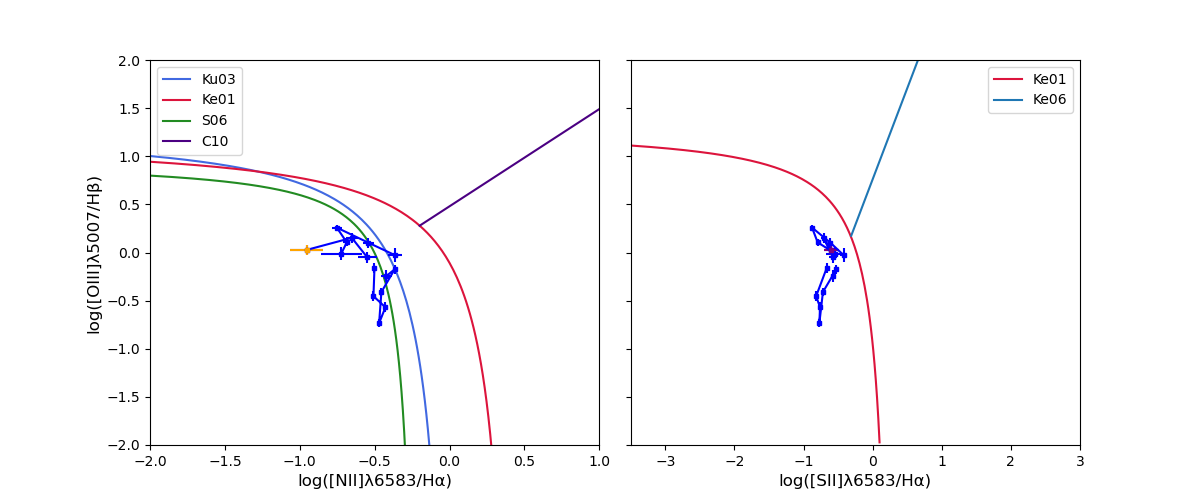

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')

x = np.linspace(-3.5, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')

NII_HA =[]
OIII_HB =[]
SII_HA =[]
NII_HA_err =[]
OIII_HB_err =[]
SII_HA_err =[]
for i in range(len(spectra)):
    SNR = evaluation_SNR(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
    if SNR == True: 
        spectrum = spectra[i]
        oiii_hb, nii_ha, sii_ha, err_oiii_hb, err_nii_ha, err_sii_ha = ratio(spectrum)
        if np.isnan(oiii_hb) == False:
            OIII_HB.append(oiii_hb)
            OIII_HB_err.append(err_oiii_hb)
        if np.isnan(sii_ha) == False:
            SII_HA.append(sii_ha)
            SII_HA_err.append(err_sii_ha)
        if np.isnan(nii_ha) == False:    
            NII_HA.append(nii_ha)
            NII_HA_err.append(err_nii_ha)
    
    else: 
        oiii_hb = np.nan
        nii_ha = np.nan
        sii_ha = np.nan
        err_oiii_hb = np.nan
        err_nii_ha = np.nan
        err_sii_ha = np.nan
        NII_HA.append(nii_ha)
        OIII_HB.append(oiii_hb)
        SII_HA.append(sii_ha)
        NII_HA_err.append(err_nii_ha)
        OIII_HB_err.append(err_oiii_hb)
        SII_HA_err.append(err_sii_ha)
        print('Nan:', i+1)
        print(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
        
OIII_HB_ok = []
SII_HA_ok = []
NII_HA_ok = []
OIII_HB_err_ok = []
SII_HA_err_ok = []
NII_HA_err_ok = []

for i in range(len(spectra)):
    if np.isnan(OIII_HB[i]) == False:
        OIII_HB_ok.append(OIII_HB[i])
        OIII_HB_err_ok.append(OIII_HB_err[i])
    if np.isnan(SII_HA[i]) == False:
        SII_HA_ok.append(SII_HA[i])
        SII_HA_err_ok.append(SII_HA_err[i])
    if np.isnan(NII_HA[i]) == False:
        NII_HA_ok.append(NII_HA[i])
        NII_HA_err_ok.append(NII_HA_err[i])
    
ax[0].errorbar(NII_HA, OIII_HB, OIII_HB_err, NII_HA_err, color='blue', marker= 's', linestyle='-', markersize = 3)   
ax[0].errorbar(NII_HA[0], OIII_HB[0], OIII_HB_err[0], NII_HA_err[0], color='red', marker= 's', linestyle='-', markersize = 3) 
ax[0].errorbar(NII_HA[-1], OIII_HB[-1], OIII_HB_err[-1], NII_HA_err[-1], color='orange', marker= 's', linestyle='-', markersize = 3) 
ax[1].errorbar(SII_HA, OIII_HB, OIII_HB_err, NII_HA_err, color='blue', marker= 's', linestyle='-', markersize = 3)
ax[1].errorbar(SII_HA[0], OIII_HB[0], OIII_HB_err[0], NII_HA_err[0], color='green', marker= 's', linestyle='-', markersize = 3)
ax[1].errorbar(SII_HA[-1], OIII_HB[-1], OIII_HB_err[-1], NII_HA_err[-1], color='purple', marker= 's', linestyle='-', markersize = 3)

ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].set_xlim(-3.5, 3)
ax[1].set_ylim(-2, 2)
ax[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.07)
#plt.savefig('BPT_grad.png', bbox_inches='tight')

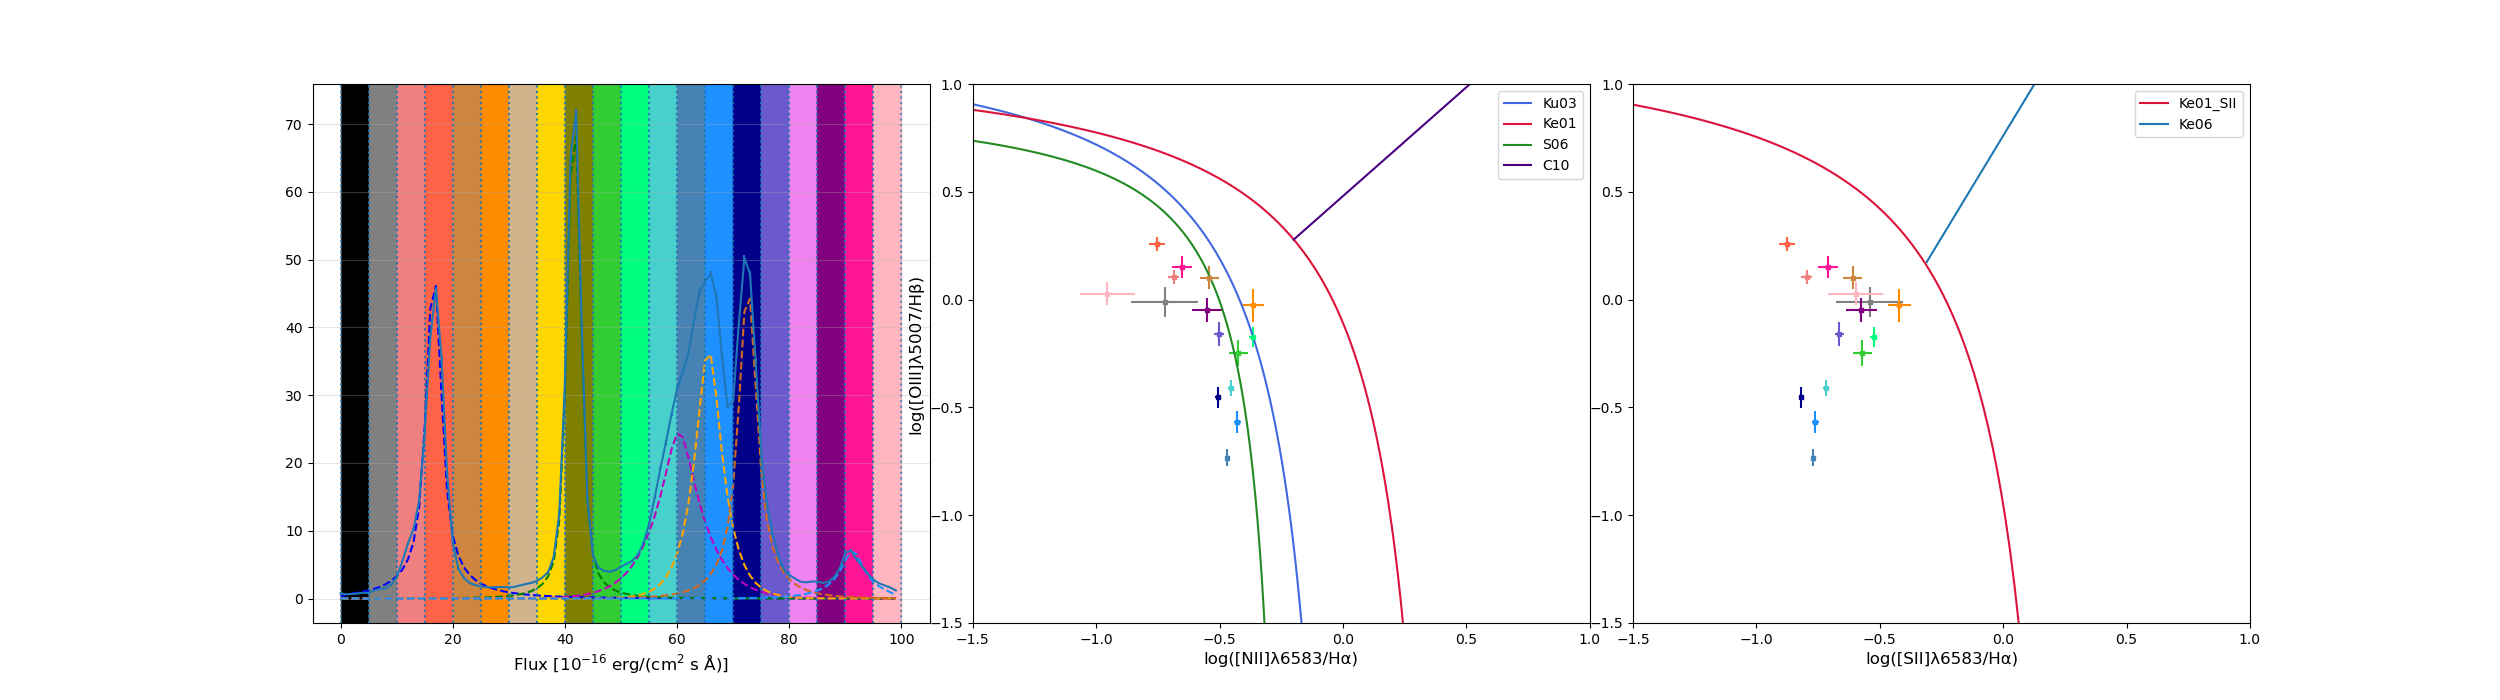

In [11]:
fig2, ax2 = plt.subplots(1, 3, figsize=(25, 7))

y_fit = model_convolved(x_axes, sigmas[0], fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'], fit['Component 5'], fit['Component 6'])

ax2[0].errorbar(x_axes, radial_profile_HA, yerr = radial_profile_error_HA, label='Data')

colors = ['b', 'g', 'm', 'orange', 'chocolate', 'dodgerblue'] 
components = ['Component 1', 'Component 2', 'Component 3', 'Component 4', 'Component 5', 'Component 6']

for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(x_axes, sigmas[0], np.array(fit[comp_name]))
        ax2[0].plot(x_axes, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
ax2[0].set_xlabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
#ax[0].legend(loc='upper right', fontsize=13)
ax2[0].grid(True, alpha=0.3)

n = 20
colors_grad = ['black', 'gray', 'lightcoral', 'tomato', 'peru', 'darkorange', 'tan', 'gold', 'olive', 'limegreen', 
               'springgreen', 'mediumturquoise', 'steelblue', 'dodgerblue', 'darkblue', 'slateblue', 'violet', 'purple',
               'deeppink', 'lightpink']
#plt.get_cmap('tab20').colors
#[cm.get_cmap('plasma')(0.3 + 0.7 * i / (n - 1)) for i in range(n)]

for i in range(20):
    x_min = i * 5
    x_max = x_min + 5
    ax2[0].axvspan(x_min, x_max, zorder=1, color = colors_grad[i])
    ax2[0].axvline(x_min, linestyle=':', linewidth=1.5, alpha=0.7)
    ax2[0].axvline(x_max, linestyle=':', linewidth=1.5, alpha=0.7)
    ax2[1].errorbar(NII_HA[i], OIII_HB[i], OIII_HB_err[i], NII_HA_err[i], color=colors_grad[i], marker= 's', linestyle='-', markersize = 3) 
    ax2[2].errorbar(SII_HA[i], OIII_HB[i], OIII_HB_err[i], NII_HA_err[i], color=colors_grad[i], marker= 's', linestyle='-', markersize = 3)
        
x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax2[1].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax2[1].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax2[1].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax2[1].plot(x3, C10(x3), label = 'C10', color = 'indigo')

x = np.linspace(-3.5, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax2[2].plot(x, Ke01_SII(x), label = 'Ke01_SII', color = 'crimson')
ax2[2].plot(x1, Ke06(x1), label = 'Ke06')

#ax2[1].errorbar(NII_HA_ok, OIII_HB_ok, OIII_HB_err_ok, NII_HA_err_ok, color='blue', marker= 's', linestyle='-', markersize = 3)   
#ax2[1].errorbar(NII_HA_ok[0], OIII_HB_ok[0], OIII_HB_err_ok[0], NII_HA_err_ok[0], color='red', marker= 's', linestyle='-', markersize = 3) 
#ax2[1].errorbar(NII_HA_ok[-1], OIII_HB_ok[-1], OIII_HB_err_ok[-1], NII_HA_err_ok[-1], color='orange', marker= 's', linestyle='-', markersize = 3) 
#ax2[2].errorbar(SII_HA_ok, OIII_HB_ok, OIII_HB_err_ok, NII_HA_err_ok, color='blue', marker= 's', linestyle='-', markersize = 3)
#ax2[2].errorbar(SII_HA_ok[0], OIII_HB_ok[0], OIII_HB_err_ok[-1], NII_HA_err_ok[0], color='green', marker= 's', linestyle='-', markersize = 3)
#ax2[2].errorbar(SII_HA_ok[-1], OIII_HB_ok[-1], OIII_HB_err_ok[-1], NII_HA_err_ok[-1], color='purple', marker= 's', linestyle='-', markersize = 3)

ax2[1].set_xlim(-1.5, 1)
ax2[1].set_ylim(-1.5, 1)
ax2[1].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax2[1].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax2[1].legend()

ax2[2].set_xlim(-1.5, 1)
ax2[2].set_ylim(-1.5, 1)
ax2[2].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax2[2].legend()

plt.subplots_adjust(wspace=0.07)